# MACHINE LEARNING (ML)

Explicação sobre o que está sendo desenvolvido...

In [52]:
# Bibliotecas que serão utilizadas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, cross_val_score

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV

In [2]:
# Carregamento da base de dados
df = pd.read_csv("vendas_aguas_LGPD_tratada.csv", delimiter=";")

df.head()

,id_cliente,dt_entrega,dt_semana,qtd_aguas_entregues,qtd_aguas_ticket,obs_pedido,dt_estacao,dt_ano,dt_mes,cli_dias_desde_ultimo_pedido,cli_intervalo_medio,cli_frequencia_pedidos,cli_media_aguas_por_pedido,cli_total_pedidos,target_dt_proxima_compra,target_dias_ate_recompra,target_vai_comprar_15d
0,89,2023-01-02,Segunda,1,03/03,NaN,Verão,2023.0,1.0,0,5.91,1,1.01,1,2023-01-11,9,1
1,102,2023-01-02,Segunda,1,0,NaN,Verão,2023.0,1.0,0,NaN,1,1.00,1,NaN,0,0
2,120,2023-01-02,Segunda,2,0,NaN,Verão,2023.0,1.0,0,14.07,1,1.93,1,2023-01-18,16,0
3,50,2023-01-02,Segunda,2,0,NaN,Verão,2023.0,1.0,0,7.80,1,2.03,1,2023-01-09,7,1
4,8,2023-01-02,Segunda,1,07/10,NaN,Verão,2023.0,1.0,0,6.15,1,1.00,1,2023-01-06,4,1


## 1º - Tratamento da base de dados para ML

Após a EDA, está sendo realizado tratamentos específicos para adequar as variáveis ao formato necessário para a modelagem, preservando as informações relevantes e evitando problemas que possam comprometer o treinamento do modelo.
As etapas contemplam a transformação de variáveis categóricas e textuais em representações numéricas, o tratamento de valores ausentes, a criação e adequação de novas variáveis, a remoção de informações que poderiam causar Data Leakage (vazamento de dados) e a exclusão de variáveis redundantes ou que não agregam informações relevantes ao modelo.

In [3]:
df_ml = df.copy()

### A) Transformação das variáveis "obs_pedido" e "dt_estacao" em binário

In [4]:
# Verificação das variáveis
df_ml[['obs_pedido', 'dt_estacao']].head()

,obs_pedido,dt_estacao
0,NaN,Verão
1,NaN,Verão
2,NaN,Verão
3,NaN,Verão
4,NaN,Verão


In [5]:
# Transformação de valores nulos da variável "obs_pedido" para 0 e valores não nulos para 1
df_ml['obs_pedido'] = df_ml['obs_pedido'].notnull().astype(int)

# Transformação de valores nulos da variável "dt_estacao" para 0 = inverno e 1 = verão
df_ml['dt_estacao'] = df_ml['dt_estacao'].map({'Inverno': 0, 'Verão': 1})

In [6]:
# Conferência da transformação
obs = df_ml['obs_pedido'].unique()
estacao = df_ml['dt_estacao'].unique()

print(f'Valores únicos da variável "obs_pedido": {obs}')
print(f'Valores únicos da variável "dt_estacao": {estacao}')

Valores únicos da variável "obs_pedido": [0 1]
Valores únicos da variável "dt_estacao": [1 0]


In [7]:
# Conferência da variável
df_ml[['obs_pedido', 'dt_estacao']].head()

,obs_pedido,dt_estacao
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1


### B) Transformação da variável "dt_semana" com One-Hot Encoding

In [8]:
# Verificação dos dados da variável
df_ml['dt_semana'].unique()

array(['Segunda', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Terça',
       'Segunda ', 'Domingo'], dtype=object)

In [9]:
# Limpeza de dados (como espaços em branco antes e depois do texto)
df_ml['dt_semana'] = df_ml['dt_semana'].str.strip()

In [10]:
# Aplicação do One-Hot Encoding e remoção da coluna original
df_ml = pd.get_dummies(df_ml, columns=['dt_semana'], dtype=int)

In [11]:
# Conferência da aplicação do One-Hot Encoding e exibição de todo dataframe
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None) 
pd.set_option('display.width', None)  

df_ml.head()

,id_cliente,dt_entrega,qtd_aguas_entregues,qtd_aguas_ticket,obs_pedido,dt_estacao,dt_ano,dt_mes,cli_dias_desde_ultimo_pedido,cli_intervalo_medio,cli_frequencia_pedidos,cli_media_aguas_por_pedido,cli_total_pedidos,target_dt_proxima_compra,target_dias_ate_recompra,target_vai_comprar_15d,dt_semana_Domingo,dt_semana_Quarta,dt_semana_Quinta,dt_semana_Segunda,dt_semana_Sexta,dt_semana_Sábado,dt_semana_Terça
0,89,2023-01-02,1,03/03,0,1,2023.0,1.0,0,5.91,1,1.01,1,2023-01-11,9,1,0,0,0,1,0,0,0
1,102,2023-01-02,1,0,0,1,2023.0,1.0,0,NaN,1,1.00,1,NaN,0,0,0,0,0,1,0,0,0
2,120,2023-01-02,2,0,0,1,2023.0,1.0,0,14.07,1,1.93,1,2023-01-18,16,0,0,0,0,1,0,0,0
3,50,2023-01-02,2,0,0,1,2023.0,1.0,0,7.80,1,2.03,1,2023-01-09,7,1,0,0,0,1,0,0,0
4,8,2023-01-02,1,07/10,0,1,2023.0,1.0,0,6.15,1,1.00,1,2023-01-06,4,1,0,0,0,1,0,0,0


### C) Imputar a mediana para a variável "cli_intervalo_medio" com valores faltantes

In [12]:
# Verificação da quantidade de valores faltantes
df_ml['cli_intervalo_medio'].isnull().sum()

np.int64(53)

In [13]:
# Calcular a mediana da variável
mediana = df_ml['cli_intervalo_medio'].median()

# Substituir os valores faltantes pela mediana
df_ml['cli_intervalo_medio'].fillna(mediana, inplace=True)

C:\Users\nneto\AppData\Local\Temp\ipykernel_12168\3129123636.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ml['cli_intervalo_medio'].fillna(mediana, inplace=True)


In [14]:
# Conferência da substituição dos valores faltantes
df_ml['cli_intervalo_medio'].isnull().sum()

np.int64(0)

### D) Exclusão da variável "cli_frequencia_pedidos"

In [15]:
# Exclusão da variável
df_ml = df_ml.drop(['cli_frequencia_pedidos'], axis=1)

In [16]:
# Conferência da exclusão da variável
df_ml.head()

,id_cliente,dt_entrega,qtd_aguas_entregues,qtd_aguas_ticket,obs_pedido,dt_estacao,dt_ano,dt_mes,cli_dias_desde_ultimo_pedido,cli_intervalo_medio,cli_media_aguas_por_pedido,cli_total_pedidos,target_dt_proxima_compra,target_dias_ate_recompra,target_vai_comprar_15d,dt_semana_Domingo,dt_semana_Quarta,dt_semana_Quinta,dt_semana_Segunda,dt_semana_Sexta,dt_semana_Sábado,dt_semana_Terça
0,89,2023-01-02,1,03/03,0,1,2023.0,1.0,0,5.91,1.01,1,2023-01-11,9,1,0,0,0,1,0,0,0
1,102,2023-01-02,1,0,0,1,2023.0,1.0,0,10.01,1.00,1,NaN,0,0,0,0,0,1,0,0,0
2,120,2023-01-02,2,0,0,1,2023.0,1.0,0,14.07,1.93,1,2023-01-18,16,0,0,0,0,1,0,0,0
3,50,2023-01-02,2,0,0,1,2023.0,1.0,0,7.80,2.03,1,2023-01-09,7,1,0,0,0,1,0,0,0
4,8,2023-01-02,1,07/10,0,1,2023.0,1.0,0,6.15,1.00,1,2023-01-06,4,1,0,0,0,1,0,0,0


### E) Transformação da variável "qtd_aguas_ticket" em registros válidos

In [17]:
# Verificação dos dados presente na variável
df_ml['qtd_aguas_ticket'].unique()

array(['03/03', '0', '07/10', '10/10', '11/15', '08/10', '15/04', '09/10',
       '02/05', '01/10', '02/15', '01/03', '02/03', '02/10', '04/10',
       '05/10', '03/10', '06/10', '15', '04/15', '06/15', '08/15',
       '10/15', '14/15', '04/16', '18', '02/18', '1', '02/08', '3',
       '02/16', '16', '01/15', '05/15', '11', '14', '12/15', '06/11',
       '03/16', '07/11', '07/16', '08/11', '07/15', '09/15', '01/12',
       '10', '13/15', '01/02', '11/05', '5', '02/02', '03/15', '2', '7',
       '8', '9', '02/04'], dtype=object)

In [18]:
# Conversão da variável "qtd_aguas_ticket" para o formato numérico
def extrair_ticket(valor):
    if pd.isna(valor):
        return pd.Series([None, None, None, 0])

    valor = str(valor).strip()

    if '/' not in valor:
        return pd.Series([None, None, None, 0])

    partes = valor.split('/')

    if len(partes) != 2:
        return pd.Series([None, None, None, 0])

    try:
        usados = int(partes[0])
        total = int(partes[1])

        if total == 0 or usados > total:
            return pd.Series([None, None, None, 0])

        percentual = usados / total

        return pd.Series([usados, total, percentual, 1])

    except ValueError:
        return pd.Series([None, None, None, 0])

# Aplicação da função para extrair os valores da variável "qtd_aguas_ticket"
df_ml[
    ['ticket_usados',
     'ticket_total',
     'ticket_percentual_uso',
     'ticket_formato_valido']
] = df_ml['qtd_aguas_ticket'].apply(extrair_ticket)

# Substituição de valores faltantes por 0
df_ml['ticket_usados'].fillna(0, inplace=True)
df_ml['ticket_total'].fillna(0, inplace=True)
df_ml['ticket_percentual_uso'].fillna(0, inplace=True)

C:\Users\nneto\AppData\Local\Temp\ipykernel_12168\2684319767.py:39: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ml['ticket_usados'].fillna(0, inplace=True)
C:\Users\nneto\AppData\Local\Temp\ipykernel_12168\2684319767.py:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [19]:
# Conferência das variáveis após a aplicação da função
df_ml.head()

,id_cliente,dt_entrega,qtd_aguas_entregues,qtd_aguas_ticket,obs_pedido,dt_estacao,dt_ano,dt_mes,cli_dias_desde_ultimo_pedido,cli_intervalo_medio,cli_media_aguas_por_pedido,cli_total_pedidos,target_dt_proxima_compra,target_dias_ate_recompra,target_vai_comprar_15d,dt_semana_Domingo,dt_semana_Quarta,dt_semana_Quinta,dt_semana_Segunda,dt_semana_Sexta,dt_semana_Sábado,dt_semana_Terça,ticket_usados,ticket_total,ticket_percentual_uso,ticket_formato_valido
0,89,2023-01-02,1,03/03,0,1,2023.0,1.0,0,5.91,1.01,1,2023-01-11,9,1,0,0,0,1,0,0,0,3.0,3.0,1.0,1.0
1,102,2023-01-02,1,0,0,1,2023.0,1.0,0,10.01,1.00,1,NaN,0,0,0,0,0,1,0,0,0,0.0,0.0,0.0,0.0
2,120,2023-01-02,2,0,0,1,2023.0,1.0,0,14.07,1.93,1,2023-01-18,16,0,0,0,0,1,0,0,0,0.0,0.0,0.0,0.0
3,50,2023-01-02,2,0,0,1,2023.0,1.0,0,7.80,2.03,1,2023-01-09,7,1,0,0,0,1,0,0,0,0.0,0.0,0.0,0.0
4,8,2023-01-02,1,07/10,0,1,2023.0,1.0,0,6.15,1.00,1,2023-01-06,4,1,0,0,0,1,0,0,0,7.0,10.0,0.7,1.0


## 2º - Duelo entre modelos: Regressão Linear x Árvore de Decisão x Random Forest

Para garantir a escolha da melhor solução para o projeto, será realizado um duelo de algoritmos comparando a Regressão Linear, a Árvore de Decisão e o Random Forest. Essa competição é fundamental porque cada modelo possui uma arquitetura matemática diferente para aprender com os dados: enquanto a Regressão Linear busca tendências diretas e retas, a Árvore de Decisão cria regras lógicas baseadas em perguntas e respostas, e o Random Forest combina dezenas dessas árvores para criar uma previsão consensual muito mais robusta. Ao testar essas três abordagens sob as mesmas condições e avaliá-las por meio de Validação Cruzada, o objetivo é identificar o modelo que apresente o menor MAE (Erro Médio Absoluto) e a maior estabilidade para prever cenários futuros, garantindo a escolha técnica mais precisa e confiável para o negócio.

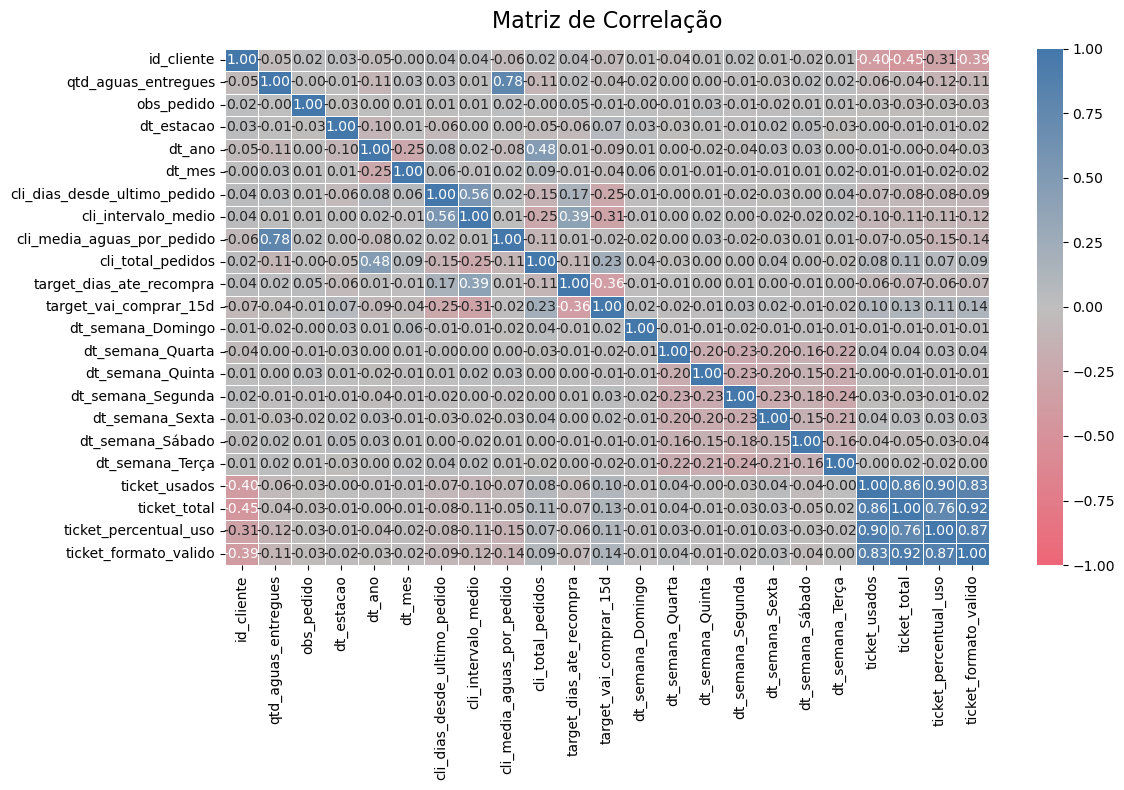

In [20]:
# Paleta de cores padrão do projeto
PALETA = {
    "azul": "#4477AA",
    "vermelho": "#EE6677",
    "verde": "#228833",
    "roxo": "#AA3377",
    "amarelo": "#C8A600",
    "cinza": "#BEBEBE",
    "preto": "#000000"
}

# Mapa de cores personalizado
cmap = LinearSegmentedColormap.from_list(
    "custom_cmap", 
    [PALETA["vermelho"], PALETA["cinza"], PALETA["azul"]]
)

# Variáveis apenas númericas para o cálculo da matriz de correlação
df_numerico = df_ml.select_dtypes(include=['number'])

# Calculo da matriz de correlação
matriz_corr = df_numerico.corr()

# Configuração do tamanho da figura
plt.figure(figsize=(12, 8))

# Mapa de calor
sns.heatmap(
    matriz_corr, 
    annot=True, 
    fmt=".2f", 
    cmap=cmap, 
    vmin=-1,
    vmax=1, 
    linewidths=0.5
)

# Título e ajuste do layout
plt.title("Matriz de Correlação", fontsize=16, pad=15)
plt.tight_layout()

# Exibição do gráfico
plt.show()

### A) Preparação da base para modelagem e treinamento

In [21]:
# Separação das variáveis independentes (X) e dependentes (y)
X = df_ml.drop([
    'id_cliente', 
    'target_dias_ate_recompra',
    'target_dt_proxima_compra', 
    'target_vai_comprar_15d', 
    'dt_entrega', 
    'qtd_aguas_ticket',
    'ticket_usados',
    'ticket_total'
], axis=1)
y = df_ml['target_dias_ate_recompra']

In [22]:
# Separação em base de treino e teste (usando 80% para treino e 20% para teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
# Conferência do tamanho das bases de treino e teste
print(f'Tamanho da base de X treino: {X_train.shape} registros')
print(f'Tamanho da base de y treino: {y_train.shape} registros')

Tamanho da base de X treino: (2485, 18) registros
Tamanho da base de y treino: (2485,) registros


### B) Regressão Linear

In [24]:
# Inicialização do modelo de Regressão Linear
modelo_LR = LinearRegression()

# Treinamento do modelo apenas com a base de treino
modelo_LR.fit(X_train, y_train)

LinearRegression()

In [25]:
# Métricas para Validação Cruzada (Cross-Validation) do modelo de Regressão Linear
# Mapeamento das métricas padrão
metricas_cv_LR = {
    'mae': 'neg_mean_absolute_error',
    'mse': 'neg_mean_squared_error',
    'r2': 'r2'
}

# Execução do Cross Validation completo usando a base de treino
# cv=5 divide o treino em 5 partes para analisar a estabilidade
resultados_cv_LR = cross_validate(modelo_LR, X_train, y_train, cv=5, scoring=metricas_cv_LR)

# Extração e correção dos valores médios do Cross Validation
cv_mae_medio_LR = -resultados_cv_LR['test_mae'].mean()
cv_rmse_medio_LR = np.sqrt(-resultados_cv_LR['test_mse']).mean()
cv_r2_medio_LR = resultados_cv_LR['test_r2'].mean()

# Avaliação do modelo com os dados de treino e teste
# Previsão usando a base de treino e teste
y_pred_train_LR = modelo_LR.predict(X_train)
y_pred_test_LR = modelo_LR.predict(X_test)

# Cálculo das métricas para a base de treino
mae_train_LR = metrics.mean_absolute_error(y_train, y_pred_train_LR)
mse_train_LR = metrics.mean_squared_error(y_train, y_pred_train_LR)
rmse_train_LR = np.sqrt(mse_train_LR)
r2_train_LR = metrics.r2_score(y_train, y_pred_train_LR)

# Cálculo das métricas para a base de teste
mae_teste_LR = metrics.mean_absolute_error(y_test, y_pred_test_LR)
mse_teste_LR = metrics.mean_squared_error(y_test, y_pred_test_LR)
rmse_teste_LR = np.sqrt(mse_teste_LR)
r2_teste_LR = metrics.r2_score(y_test, y_pred_test_LR)

# Exibição de tabela comparativa estruturada
print('Cross Validation da métrica: MAE')
print(f"MAE CV (Médio): {cv_mae_medio_LR:.2f} | MAE Teste: {mae_teste_LR:.2f}")
print('-' * 55)
print(f'{"Métrica":<15} {"Treino":<10} {"Teste":<10} {"CV (Médio)":<10}')
print('-' * 55)
print(f'{"R²":<15} {r2_train_LR:<10.4f} {r2_teste_LR:<10.4f} {cv_r2_medio_LR:<10.4f}')
print(f'{"MAE":<15} {mae_train_LR:<10.2f} {mae_teste_LR:<10.2f} {cv_mae_medio_LR:<10.2f}')
print(f'{"MSE":<15} {mse_train_LR:<10.2f} {mse_teste_LR:<10.2f} {mse_teste_LR:<10.2f}')
print(f'{"RMSE":<15} {rmse_train_LR:<10.2f} {rmse_teste_LR:<10.2f} {cv_rmse_medio_LR:<10.2f}')

Cross Validation da métrica: MAE
MAE CV (Médio): 8.04 | MAE Teste: 10.48
-------------------------------------------------------
Métrica         Treino     Teste      CV (Médio)
-------------------------------------------------------
R²              0.1386     0.1635     0.1377    
MAE             7.84       10.48      8.04      
MSE             662.21     1277.68    1277.68   
RMSE            25.73      35.74      25.60     


**Avaliação:** \
A validação cruzada apresentou R² médio de 13,77% e MAE médio de 8,04 dias, resultados próximos aos observados no conjunto de treino. No entanto, o MAE no teste foi superior, de 10,48 dias, indicando uma piora no desempenho para dados não utilizados no treinamento. De forma geral, o modelo apresenta baixo poder explicativo, reforçando que uma relação linear simples não é suficiente para representar adequadamente o comportamento do tempo até a recompra.

### C) Árvore de Decisão

In [26]:
# Inicialização do modelo de Regressão de Árvore de Decisão
modelo_AD = DecisionTreeRegressor(max_depth=5, random_state=42)

# Treinamento do modelo apenas com a base de treino
modelo_AD.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [27]:
# Métricas para Validação Cruzada (Cross-Validation) do modelo de Árvore de Decisão
# Mapeamento das métricas padrão
metricas_cv_AD = {
    'mae': 'neg_mean_absolute_error',
    'mse': 'neg_mean_squared_error',
    'r2': 'r2'
}

# Execução do Cross Validation completo usando a base de treino
# cv=5 divide o treino em 5 partes para analisar a estabilidade
resultados_cv_AD = cross_validate(modelo_AD, X_train, y_train, cv=5, scoring=metricas_cv_AD)

# Extração e correção dos valores médios do Cross Validation
cv_mae_medio_AD = -resultados_cv_AD['test_mae'].mean()
cv_rmse_medio_AD = np.sqrt(-resultados_cv_AD['test_mse']).mean()
cv_r2_medio_AD = resultados_cv_AD['test_r2'].mean()

# Geração das previsões para a base de treino e teste
y_pred_train_AD = modelo_AD.predict(X_train)
y_pred_test_AD = modelo_AD.predict(X_test)

# Cálculo das métricas para a base de treino
mae_train_AD = metrics.mean_absolute_error(y_train, y_pred_train_AD)
mse_train_AD = metrics.mean_squared_error(y_train, y_pred_train_AD)
rmse_train_AD = np.sqrt(mse_train_AD)
r2_train_AD = metrics.r2_score(y_train, y_pred_train_AD)

# Cálculo das métricas para a base de teste
mae_teste_AD = metrics.mean_absolute_error(y_test, y_pred_test_AD)
mse_teste_AD = metrics.mean_squared_error(y_test, y_pred_test_AD)
rmse_teste_AD = np.sqrt(mse_teste_AD)
r2_teste_AD = metrics.r2_score(y_test, y_pred_test_AD)

# Exibição de tabela comparativa estruturada
print('Cross Validation da métrica: MAE')
print(f"MAE CV (Médio): {cv_mae_medio_AD:.2f} | MAE Teste: {mae_teste_AD:.2f}")
print('-' * 55)
print(f'{"Métrica":<15} {"Treino":<10} {"Teste":<10} {"CV (Médio)":<10}')
print('-' * 55)
print(f'{"R²":<15} {r2_train_AD:<10.4f} {r2_teste_AD:<10.4f} {cv_r2_medio_AD:<10.4f}')
print(f'{"MAE":<15} {mae_train_AD:<10.2f} {mae_teste_AD:<10.2f} {cv_mae_medio_AD:<10.2f}')
print(f'{"MSE":<15} {mse_train_AD:<10.2f} {mse_teste_AD:<10.2f} {mse_teste_AD:<10.2f}')
print(f'{"RMSE":<15} {rmse_train_AD:<10.2f} {rmse_teste_AD:<10.2f} {cv_rmse_medio_AD:<10.2f}')

Cross Validation da métrica: MAE
MAE CV (Médio): 8.66 | MAE Teste: 11.49
-------------------------------------------------------
Métrica         Treino     Teste      CV (Médio)
-------------------------------------------------------
R²              0.3831     -0.1066    -0.1921   
MAE             6.92       11.49      8.66      
MSE             474.29     1690.13    1690.13   
RMSE            21.78      41.11      30.04     


**Avaliação:** \
A validação cruzada apresentou R² médio de -19,21% e MAE médio de 8,66 dias, enquanto o conjunto de teste apresentou R² de -10,66%, MAE de 11,49 dias e RMSE de 41,11 dias. Apesar do melhor ajuste no treino (R² = 38,31%), o desempenho negativo na validação e no teste evidencia baixa capacidade de generalização e forte indício de sobreajuste, indicando que o modelo não representa adequadamente o comportamento de recompra fora dos dados de treinamento.

### D) Random Forest

In [28]:
# Inicialização do modelo de Random Forest
modelo_RF = RandomForestClassifier(random_state=42)

# Treinamento do modelo com a base de treino
modelo_RF.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [29]:
# Métricas para Validação Cruzada (Cross-Validation) do modelo Random Forest
# Mapeamento das métricas padrão
metricas_cv_RF = {
    'mae': 'neg_mean_absolute_error',
    'mse': 'neg_mean_squared_error',
    'r2': 'r2'
}

# Execução do Cross Validation completo usando a base de treino
# cv=5 divide o treino em 5 partes para analisar a estabilidade
resultados_cv_RF = cross_validate(modelo_RF, X_train, y_train, cv=5, scoring=metricas_cv_RF)

# Extração e correção dos valores médios do Cross Validation
cv_mae_medio_RF = -resultados_cv_RF['test_mae'].mean()
cv_rmse_medio_RF = np.sqrt(-resultados_cv_RF['test_mse']).mean()
cv_r2_medio_RF = resultados_cv_RF['test_r2'].mean()

# Geração das previsões para a base de treino e teste
y_pred_train_RF = modelo_RF.predict(X_train)
y_pred_test_RF = modelo_RF.predict(X_test)

# Cálculo das métricas para a base de treino
mae_train_RF = metrics.mean_absolute_error(y_train, y_pred_train_RF)
mse_train_RF = metrics.mean_squared_error(y_train, y_pred_train_RF)
rmse_train_RF = np.sqrt(mse_train_RF)
r2_train_RF = metrics.r2_score(y_train, y_pred_train_RF)

# Cálculo das métricas para a base de teste
mae_teste_RF = metrics.mean_absolute_error(y_test, y_pred_test_RF)
mse_teste_RF = metrics.mean_squared_error(y_test, y_pred_test_RF)
rmse_teste_RF = np.sqrt(mse_teste_RF)
r2_teste_RF = metrics.r2_score(y_test, y_pred_test_RF)

# Exibição de tabela comparativa estruturada
print('Cross Validation da métrica: MAE')
print(f"MAE CV (Médio): {cv_mae_medio_RF:.2f} | MAE Teste: {mae_teste_RF:.2f}")
print('-' * 55)
print(f'{"Métrica":<15} {"Treino":<10} {"Teste":<10} {"CV (Médio)":<10}')
print('-' * 55)
print(f'{"R²":<15} {r2_train_RF:<10.4f} {r2_teste_RF:<10.4f} {cv_r2_medio_RF:<10.4f}')
print(f'{"MAE":<15} {mae_train_RF:<10.2f} {mae_teste_RF:<10.2f} {cv_mae_medio_RF:<10.2f}')
print(f'{"MSE":<15} {mse_train_RF:<10.2f} {mse_teste_RF:<10.2f} {mse_teste_RF:<10.2f}')
print(f'{"RMSE":<15} {rmse_train_RF:<10.2f} {rmse_teste_RF:<10.2f} {cv_rmse_medio_RF:<10.2f}')

c:\Users\nneto\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Cross Validation da métrica: MAE
MAE CV (Médio): 8.96 | MAE Teste: 9.83
-------------------------------------------------------
Métrica         Treino     Teste      CV (Médio)
-------------------------------------------------------
R²              1.0000     0.0054     -0.5030   
MAE             0.00       9.83       8.96      
MSE             0.00       1519.10    1519.10   
RMSE            0.00       38.98      33.44     


**Avaliação:** \
O Random Forest apresentou R² de 100% no treino, com erro praticamente nulo, mas caiu para 0,54% no teste. Na validação cruzada, o R² médio foi de -50,30%, enquanto o MAE médio foi de 8,96 dias, próximo ao MAE de 9,83 dias no teste. Esse comportamento evidencia baixa capacidade de generalização e forte indício de overfitting.

Esse resultado deve ser interpretado considerando que o modelo foi inicialmente executado sem definição de hiperparâmetros. Dessa forma, a alta complexidade padrão do modelo pode ter permitido um ajuste excessivo aos dados de treinamento. A etapa de otimização dos hiperparâmetros será importante para avaliar se é possível controlar esse sobreajuste e melhorar sua capacidade de generalização.

### Análise e avaliação completa dos modelos

In [30]:
# Dicionário estruturado com as variáveis de cada modelo
dados_comparativos = {
    'Modelo': ['Regressão Linear', 'Árvore de Decisão', 'Random Forest'],

    # Métrica principal (MAE)
    'MAE Treino': [mae_train_LR, mae_train_AD, mae_train_RF],
    'MAE Teste': [mae_teste_LR, mae_teste_AD, mae_teste_RF],
    'MAE CV': [cv_mae_medio_LR, cv_mae_medio_AD, cv_mae_medio_RF],

    # Métricas de suporte (RMSE e R²)
    'RMSE CV (Médio)': [cv_rmse_medio_LR, cv_rmse_medio_AD, cv_rmse_medio_RF],
    'R² CV (Médio)': [cv_r2_medio_LR, cv_r2_medio_AD, cv_r2_medio_RF]
}

# Transformação do dicionário em DataFrame
df_comparativo = pd.DataFrame(dados_comparativos)

# Ordenar a tabela pelo MAE do Cross-Validation (Menor erro primeiro)
df_comparativo.sort_values(by='MAE CV', ascending=True, inplace=True)

# Exibir os resultados final formatado
print('-' * 80)
print('\t     🏆 TABELA COMPARATIVA GERAL DE MODELOS (Foco no MAE)')
print('-' * 80)
df_estilizado = df_comparativo.style.format({
    'MAE Treino': '{:.2f}',
    'MAE Teste': '{:.2f}',
    'MAE CV': '{:.2f}',
    'RMSE CV (Médio)': '{:.2f}',
    'R² CV (Médio)': '{:.4f}'
}).hide(axis='index')
display(df_estilizado)

--------------------------------------------------------------------------------
	     🏆 TABELA COMPARATIVA GERAL DE MODELOS (Foco no MAE)
--------------------------------------------------------------------------------


Modelo,MAE Treino,MAE Teste,MAE CV,RMSE CV (Médio),R² CV (Médio)
Regressão Linear,7.84,10.48,8.04,25.60,0.1377
Árvore de Decisão,6.92,11.49,8.66,30.04,-0.1921
Random Forest,0.00,9.83,8.96,33.44,-0.5030


**Comparação:** \
Considerando o MAE como principal métrica, por representar diretamente o erro médio das previsões em dias, a Regressão Linear apresentou o melhor desempenho na validação cruzada, com MAE médio de 8,04 dias, seguida pela Árvore de Decisão (8,66 dias) e pelo Random Forest (8,96 dias).

Além disso, a Regressão Linear apresentou o melhor R² médio na validação cruzada (13,77%) e o menor RMSE médio (25,60 dias), indicando maior estabilidade e capacidade de generalização entre os modelos avaliados. A Árvore de Decisão apresentou R² negativo (-19,21%), enquanto o Random Forest apresentou o pior resultado nesse indicador (-50,30%).

Embora o Random Forest tenha apresentado o menor MAE no conjunto de teste (9,83 dias), seu desempenho na validação cruzada foi inferior e apresentou forte diferença entre treino e validação, com MAE de 0,00 no treino e R² médio de -50,30%, evidenciando sobreajuste.

**Modelo selecionado**

Diante dos resultados, a Regressão Linear será selecionada para a próxima etapa de desenvolvimento, por apresentar o melhor equilíbrio entre MAE, RMSE e R² na validação cruzada, além de demonstrar maior estabilidade e menor indício de sobreajuste.

A partir dela, serão exploradas diferentes configurações e técnicas de preparação das variáveis, buscando verificar se é possível melhorar sua capacidade de previsão e reduzir o erro médio das estimativas de dias até a recompra.

## 3º - Otimização e avaliação do modelo de Regressão Linear

In [31]:
# Métricas para Validação Cruzada (Cross-Validation) do modelo de Regressão Linear
# Mapeamento das métricas padrão
metricas_cv = {
    'mae': 'neg_mean_absolute_error',
    'mse': 'neg_mean_squared_error',
    'r2': 'r2'
}

### A) Teste de diferentes conjuntos de variáveis para o modelo

#### Modelo A - Todas as variáveis

In [32]:
# Modelo atual
# Reexibição dos resultados
print('Cross Validation da métrica: MAE')
print(f"MAE CV (Médio): {cv_mae_medio_LR:.2f} | MAE Teste: {mae_teste_LR:.2f}")
print('-' * 55)
print(f'{"Métrica":<15} {"Treino":<10} {"Teste":<10} {"CV (Médio)":<10}')
print('-' * 55)
print(f'{"R²":<15} {r2_train_LR:<10.4f} {r2_teste_LR:<10.4f} {cv_r2_medio_LR:<10.4f}')
print(f'{"MAE":<15} {mae_train_LR:<10.2f} {mae_teste_LR:<10.2f} {cv_mae_medio_LR:<10.2f}')
print(f'{"MSE":<15} {mse_train_LR:<10.2f} {mse_teste_LR:<10.2f} {mse_teste_LR:<10.2f}')
print(f'{"RMSE":<15} {rmse_train_LR:<10.2f} {rmse_teste_LR:<10.2f} {cv_rmse_medio_LR:<10.2f}')


Cross Validation da métrica: MAE
MAE CV (Médio): 8.04 | MAE Teste: 10.48
-------------------------------------------------------
Métrica         Treino     Teste      CV (Médio)
-------------------------------------------------------
R²              0.1386     0.1635     0.1377    
MAE             7.84       10.48      8.04      
MSE             662.21     1277.68    1277.68   
RMSE            25.73      35.74      25.60     


#### Modelo B - Variáveis comportamentais

In [33]:
# Definição das variáveis comportamentais
X_b = df_ml[[
    'qtd_aguas_entregues', 'cli_dias_desde_ultimo_pedido', 'cli_intervalo_medio',
    'cli_media_aguas_por_pedido', 'cli_total_pedidos', 'ticket_percentual_uso',
    'ticket_formato_valido']]

In [34]:
# Separação em base de treino e teste (usando 80% para treino e 20% para teste)
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_b, y, test_size=0.2, random_state=42)

In [35]:
# Inicialização do modelo de Regressão Linear com as variáveis comportamentais definidas
modelo_b = LinearRegression()

# Treinamento do modelo apenas com a base de treino
modelo_b.fit(X_train_b, y_train_b)

LinearRegression()

In [36]:
# Execução do Cross Validation completo usando a base de treino
# cv=5 divide o treino em 5 partes para analisar a estabilidade
resultados_cv_b = cross_validate(modelo_b, X_train_b, y_train_b, cv=5, scoring=metricas_cv)

# Extração e correção dos valores médios do Cross Validation
cv_mae_medio_b = -resultados_cv_b['test_mae'].mean()
cv_rmse_medio_b = np.sqrt(-resultados_cv_b['test_mse']).mean()
cv_r2_medio_b = resultados_cv_b['test_r2'].mean()

# Avaliação do modelo com os dados de treino e teste
# Previsão usando a base de treino e teste
y_pred_train_b = modelo_b.predict(X_train_b)
y_pred_test_b = modelo_b.predict(X_test_b)

# Cálculo das métricas para a base de treino
mae_train_b = metrics.mean_absolute_error(y_train_b, y_pred_train_b)
mse_train_b = metrics.mean_squared_error(y_train_b, y_pred_train_b)
rmse_train_b = np.sqrt(mse_train_b)
r2_train_b = metrics.r2_score(y_train_b, y_pred_train_b)

# Cálculo das métricas para a base de teste
mae_teste_b = metrics.mean_absolute_error(y_test_b, y_pred_test_b)
mse_teste_b = metrics.mean_squared_error(y_test_b, y_pred_test_b)
rmse_teste_b = np.sqrt(mse_teste_b)
r2_teste_b = metrics.r2_score(y_test_b, y_pred_test_b)

# Exibição de tabela comparativa estruturada
print('Cross Validation da métrica: MAE')
print(f"MAE CV (Médio): {cv_mae_medio_b:.2f} | MAE Teste: {mae_teste_b:.2f}")
print('-' * 55)
print(f'{"Métrica":<15} {"Treino":<10} {"Teste":<10} {"CV (Médio)":<10}')
print('-' * 55)
print(f'{"R²":<15} {r2_train_b:<10.4f} {r2_teste_b:<10.4f} {cv_r2_medio_b:<10.4f}')
print(f'{"MAE":<15} {mae_train_b:<10.2f} {mae_teste_b:<10.2f} {cv_mae_medio_b:<10.2f}')
print(f'{"MSE":<15} {mse_train_b:<10.2f} {mse_teste_b:<10.2f} {mse_teste_b:<10.2f}')
print(f'{"RMSE":<15} {rmse_train_b:<10.2f} {rmse_teste_b:<10.2f} {cv_rmse_medio_b:<10.2f}')

Cross Validation da métrica: MAE
MAE CV (Médio): 7.81 | MAE Teste: 10.19
-------------------------------------------------------
Métrica         Treino     Teste      CV (Médio)
-------------------------------------------------------
R²              0.1294     0.1682     0.1399    
MAE             7.75       10.19      7.81      
MSE             669.31     1270.42    1270.42   
RMSE            25.87      35.64      25.56     


**Análise:** \
A definição apenas das variáveis comportamentais apresentou baixo poder explicativo, com R² de 0,1682 no teste, indicando que as variáveis comportamentais utilizadas explicam apenas uma parcela limitada da variação dos dias até a recompra. O MAE de 10,19 dias demonstra um erro médio elevado, enquanto a diferença entre treino (7,75 dias) e teste (10,19 dias) indica perda de desempenho na generalização. A Validação Cruzada apresentou MAE médio de 7,81 dias, sugerindo desempenho mais próximo ao treino.

#### Modelo C - Comportamento + temporal

In [37]:
# Definição das variáveis comportamentais e temporais
X_c = df_ml[[
    'qtd_aguas_entregues', 'cli_dias_desde_ultimo_pedido', 'cli_intervalo_medio',
    'cli_media_aguas_por_pedido', 'cli_total_pedidos', 'ticket_percentual_uso',
    'ticket_formato_valido', 'dt_estacao', 'dt_mes', 'dt_semana_Domingo',
    'dt_semana_Quarta', 'dt_semana_Quinta', 'dt_semana_Segunda', 'dt_semana_Sexta',
    'dt_semana_Sábado', 'dt_semana_Terça']]

In [38]:
# Separação em base de treino e teste (usando 80% para treino e 20% para teste)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y, test_size=0.2, random_state=42)

In [39]:
# Inicialização do modelo de Regressão Linear com as variáveis comportamentais e temporais definidas
modelo_c = LinearRegression()

# Treinamento do modelo apenas com a base de treino
modelo_c.fit(X_train_c, y_train_c)

LinearRegression()

In [40]:
# Execução do Cross Validation completo usando a base de treino
# cv=5 divide o treino em 5 partes para analisar a estabilidade
resultados_cv_c = cross_validate(modelo_c, X_train_c, y_train_c, cv=5, scoring=metricas_cv)

# Extração e correção dos valores médios do Cross Validation
cv_mae_medio_c = -resultados_cv_c['test_mae'].mean()
cv_rmse_medio_c = np.sqrt(-resultados_cv_c['test_mse']).mean()
cv_r2_medio_c = resultados_cv_c['test_r2'].mean()

# Avaliação do modelo com os dados de treino e teste
# Previsão usando a base de treino e teste
y_pred_train_c = modelo_c.predict(X_train_c)
y_pred_test_c = modelo_c.predict(X_test_c)

# Cálculo das métricas para a base de treino
mae_train_c = metrics.mean_absolute_error(y_train_c, y_pred_train_c)
mse_train_c = metrics.mean_squared_error(y_train_c, y_pred_train_c)
rmse_train_c = np.sqrt(mse_train_c)
r2_train_c = metrics.r2_score(y_train_c, y_pred_train_c)

# Cálculo das métricas para a base de teste
mae_teste_c = metrics.mean_absolute_error(y_test_c, y_pred_test_c)
mse_teste_c = metrics.mean_squared_error(y_test_c, y_pred_test_c)
rmse_teste_c = np.sqrt(mse_teste_c)
r2_teste_c = metrics.r2_score(y_test_c, y_pred_test_c)

# Exibição de tabela comparativa estruturada
print('Cross Validation da métrica: MAE')
print(f"MAE CV (Médio): {cv_mae_medio_c:.2f} | MAE Teste: {mae_teste_c:.2f}")
print('-' * 55)
print(f'{"Métrica":<15} {"Treino":<10} {"Teste":<10} {"CV (Médio)":<10}')
print('-' * 55)
print(f'{"R²":<15} {r2_train_c:<10.4f} {r2_teste_c:<10.4f} {cv_r2_medio_c:<10.4f}')
print(f'{"MAE":<15} {mae_train_c:<10.2f} {mae_teste_c:<10.2f} {cv_mae_medio_c:<10.2f}')
print(f'{"MSE":<15} {mse_train_c:<10.2f} {mse_teste_c:<10.2f} {mse_teste_c:<10.2f}')
print(f'{"RMSE":<15} {rmse_train_c:<10.2f} {rmse_teste_c:<10.2f} {cv_rmse_medio_c:<10.2f}')

Cross Validation da métrica: MAE
MAE CV (Médio): 7.93 | MAE Teste: 10.42
-------------------------------------------------------
Métrica         Treino     Teste      CV (Médio)
-------------------------------------------------------
R²              0.1351     0.1693     0.1390    
MAE             7.80       10.42      7.93      
MSE             664.91     1268.80    1268.80   
RMSE            25.79      35.62      25.57     


**Análise:** \
A definição das variáveis comportamentais e temporais apresentou baixo poder explicativo, com R² de 0,1693 no teste, indicando que as variáveis comportamentais e temporais utilizadas explicam uma parcela limitada da variação dos dias até a recompra. O MAE de 10,42 dias representa um erro médio elevado nas previsões. A Validação Cruzada apresentou MAE médio de 7,93 dias, próximo ao valor observado no treino (7,80), enquanto o RMSE de teste (35,62) evidencia a presença de erros de maior magnitude.

#### Modelo D - Variáveis com maior relação com a target

In [41]:
# Definição das variáveis com maior relação com a target
X_d= df_ml[[
    'cli_intervalo_medio',
    'cli_total_pedidos'
]]

In [42]:
# Separação em base de treino e teste (usando 80% para treino e 20% para teste)
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_d, y, test_size=0.2, random_state=42)

In [43]:
# Inicialização do modelo de Regressão Linear com as variáveis com maior relação com a target
modelo_d = LinearRegression()

# Treinamento do modelo apenas com a base de treino
modelo_d.fit(X_train_d, y_train_d)

LinearRegression()

In [44]:
# Execução do Cross Validation completo usando a base de treino
# cv=5 divide o treino em 5 partes para analisar a estabilidade
resultados_cv_d = cross_validate(modelo_d, X_train_d, y_train_d, cv=5, scoring=metricas_cv)

# Extração e correção dos valores médios do Cross Validation
cv_mae_medio_d = -resultados_cv_d['test_mae'].mean()
cv_rmse_medio_d = np.sqrt(-resultados_cv_d['test_mse']).mean()
cv_r2_medio_d = resultados_cv_d['test_r2'].mean()

# Avaliação do modelo com os dados de treino e teste
# Previsão usando a base de treino e teste
y_pred_train_d = modelo_d.predict(X_train_d)
y_pred_test_d = modelo_d.predict(X_test_d)

# Cálculo das métricas para a base de treino
mae_train_d = metrics.mean_absolute_error(y_train_d, y_pred_train_d)
mse_train_d = metrics.mean_squared_error(y_train_d, y_pred_train_d)
rmse_train_d = np.sqrt(mse_train_d)
r2_train_d = metrics.r2_score(y_train_d, y_pred_train_d)

# Cálculo das métricas para a base de teste
mae_teste_d = metrics.mean_absolute_error(y_test_d, y_pred_test_d)
mse_teste_d = metrics.mean_squared_error(y_test_d, y_pred_test_d)
rmse_teste_d = np.sqrt(mse_teste_d)
r2_teste_d = metrics.r2_score(y_test_d, y_pred_test_d)

# Exibição de tabela comparativa estruturada
print('Cross Validation da métrica: MAE')
print(f"MAE CV (Médio): {cv_mae_medio_d:.2f} | MAE Teste: {mae_teste_d:.2f}")
print('-' * 55)
print(f'{"Métrica":<15} {"Treino":<10} {"Teste":<10} {"CV (Médio)":<10}')
print('-' * 55)
print(f'{"R²":<15} {r2_train_d:<10.4f} {r2_teste_d:<10.4f} {cv_r2_medio_d:<10.4f}')
print(f'{"MAE":<15} {mae_train_d:<10.2f} {mae_teste_d:<10.2f} {cv_mae_medio_d:<10.2f}')
print(f'{"MSE":<15} {mse_train_d:<10.2f} {mse_teste_d:<10.2f} {mse_teste_d:<10.2f}')
print(f'{"RMSE":<15} {rmse_train_d:<10.2f} {rmse_teste_d:<10.2f} {cv_rmse_medio_d:<10.2f}')

Cross Validation da métrica: MAE
MAE CV (Médio): 7.83 | MAE Teste: 10.18
-------------------------------------------------------
Métrica         Treino     Teste      CV (Médio)
-------------------------------------------------------
R²              0.1284     0.1747     0.1414    
MAE             7.78       10.18      7.83      
MSE             670.06     1260.58    1260.58   
RMSE            25.89      35.50      25.54     


**Análise:** \
A definição das variáveis com maior relação com a target apresentou baixo poder explicativo, com R² de 0,1747 no teste, indicando que as variáveis selecionadas explicam uma parcela limitada da variação dos dias até a recompra. O MAE de 10,18 dias representa o erro médio das previsões, enquanto o RMSE de 35,50 indica a ocorrência de erros de maior magnitude. A Validação Cruzada apresentou MAE médio de 7,83 dias e R² de 0,1414, demonstrando desempenho relativamente consistente entre os subconjuntos avaliados.

#### Análise e avaliação completa dos modelos

In [45]:
# Dicionário estruturado com as variáveis de cada modelo
dados_comparativos_modelos = {
    'Modelo': ['Modelo A - Todas as variáveis', 'Modelo B - Variáveis comportamentais', 
               'Modelo C - Comportamento + temporal', 'Modelo D - Variáveis com maior relação com a target'],

    # Métrica principal (MAE)
    'MAE Treino': [mae_train_LR, mae_train_b, mae_train_c, mae_train_d],
    'MAE Teste': [mae_teste_LR, mae_teste_b, mae_teste_c, mae_teste_d],
    'MAE CV': [cv_mae_medio_LR, cv_mae_medio_b, cv_mae_medio_c, cv_mae_medio_d],

    # Métricas de suporte (RMSE e R²)
    'RMSE CV (Médio)': [cv_rmse_medio_LR, cv_rmse_medio_b, cv_rmse_medio_c, cv_rmse_medio_d],
    'R² CV (Médio)': [cv_r2_medio_LR, cv_r2_medio_b, cv_r2_medio_c, cv_r2_medio_d]
}

# Transformação do dicionário em DataFrame
df_comparativo_modelos = pd.DataFrame(dados_comparativos_modelos)

# Ordenar a tabela pelo MAE do Cross-Validation (Menor erro primeiro)
df_comparativo_modelos.sort_values(by='MAE CV', ascending=True, inplace=True)

# Exibir os resultados final formatado
print('-' * 108)
print('\t\t\t     🏆 TABELA COMPARATIVA GERAL DE MODELOS (Foco no MAE)')
print('-' * 108)
df_estilizado_modelos = df_comparativo_modelos.style.format({
    'MAE Treino': '{:.2f}',
    'MAE Teste': '{:.2f}',
    'MAE CV': '{:.2f}',
    'RMSE CV (Médio)': '{:.2f}',
    'R² CV (Médio)': '{:.4f}'
}).hide(axis='index')
display(df_estilizado_modelos)

------------------------------------------------------------------------------------------------------------
			     🏆 TABELA COMPARATIVA GERAL DE MODELOS (Foco no MAE)
------------------------------------------------------------------------------------------------------------


Modelo,MAE Treino,MAE Teste,MAE CV,RMSE CV (Médio),R² CV (Médio)
Modelo B - Variáveis comportamentais,7.75,10.19,7.81,25.56,0.1399
Modelo D - Variáveis com maior relação com a target,7.78,10.18,7.83,25.54,0.1414
Modelo C - Comportamento + temporal,7.80,10.42,7.93,25.57,0.1390
Modelo A - Todas as variáveis,7.84,10.48,8.04,25.60,0.1377


**Comparação:** \
A comparação mostra uma melhora gradual conforme o conjunto de variáveis é reduzido e direcionado ao comportamento dos clientes.

Modelo A – Todas as variáveis: apresentou o pior resultado, com MAE CV de 8,04 dias e R² CV de 0,1377.
Modelo C – Comportamento + temporal: apresentou melhora em relação ao Modelo A, mas o MAE CV de 7,93 dias ainda ficou acima dos modelos mais enxutos.
Modelo D – Variáveis com maior relação com a target: apresentou R² CV ligeiramente superior (0,1414) e o menor RMSE CV (25,54), porém seu MAE CV foi 7,83 dias.
Modelo B – Variáveis comportamentais: apresentou o menor MAE CV (7,81 dias), além do menor MAE de teste (10,19 dias), indicando o melhor desempenho preditivo entre as configurações avaliadas.

**Modelo selecionado**

O Modelo B – Variáveis comportamentais será utilizado como base para a próxima etapa de otimização.

A escolha é principalmente orientada pelo MAE, métrica prioritária do projeto, pois representa diretamente o erro médio das previsões em dias. O modelo apresentou:

MAE Treino: 7,75 dias
MAE Teste: 10,19 dias
MAE CV: 7,81 dias
RMSE CV: 25,56 dias
R² CV: 0,1399

Embora o Modelo D tenha apresentado R² CV ligeiramente maior, a diferença é pequena, enquanto o Modelo B possui o menor MAE tanto no teste quanto na validação cruzada. Portanto, ele oferece o melhor equilíbrio para o objetivo de prever os dias até a recompra.

### B) Teste de interações

In [46]:
# Criação da cópia para preservação da base original
X_otimizado = X_b.copy()

# Aplicação das interações
# Índice de urgência de compra
X_otimizado['int_indice_urgencia'] = X_otimizado['cli_dias_desde_ultimo_pedido'] * X_otimizado['cli_intervalo_medio']

# Volume de consumo acumulado
X_otimizado['int_consumo_acumulado'] = X_otimizado['cli_media_aguas_por_pedido'] * X_otimizado['cli_total_pedidos']

In [47]:
# Separação em base de treino e teste (usando 80% para treino e 20% para teste)
X_train_otm, X_test_otm, y_train_otm, y_test_otm = train_test_split(X_otimizado, y, test_size=0.2, random_state=42)

In [ ]:
# Inicialização do modelo de Regressão Linear utilizando teste de interações
modelo_otm = LinearRegression()

# Treinamento do modelo apenas com a base de treino
modelo_otm.fit(X_train_otm, y_train_otm)

LinearRegression()

In [49]:
# Execução do Cross Validation completo usando a base de treino
# cv=5 divide o treino em 5 partes para analisar a estabilidade
resultados_cv_otm = cross_validate(modelo_otm, X_train_otm, y_train_otm, cv=5, scoring=metricas_cv)

# Extração e correção dos valores médios do Cross Validation
cv_mae_medio_otm = -resultados_cv_otm['test_mae'].mean()
cv_rmse_medio_otm = np.sqrt(-resultados_cv_otm['test_mse']).mean()
cv_r2_medio_otm = resultados_cv_otm['test_r2'].mean()

# Avaliação do modelo com os dados de treino e teste
# Previsão usando a base de treino e teste
y_pred_train_otm = modelo_otm.predict(X_train_otm)
y_pred_test_otm = modelo_otm.predict(X_test_otm)

# Cálculo das métricas para a base de treino
mae_train_otm = metrics.mean_absolute_error(y_train_otm, y_pred_train_otm)
mse_train_otm = metrics.mean_squared_error(y_train_otm, y_pred_train_otm)
rmse_train_otm = np.sqrt(mse_train_otm)
r2_train_otm = metrics.r2_score(y_train_otm, y_pred_train_otm)

# Cálculo das métricas para a base de teste
mae_teste_otm = metrics.mean_absolute_error(y_test_otm, y_pred_test_otm)
mse_teste_otm = metrics.mean_squared_error(y_test_otm, y_pred_test_otm)
rmse_teste_otm = np.sqrt(mse_teste_otm)
r2_teste_otm = metrics.r2_score(y_test_d, y_pred_test_otm)

# Exibição de tabela comparativa estruturada
print('Cross Validation da métrica: MAE')
print(f"MAE CV (Médio): {cv_mae_medio_otm:.2f} | MAE Teste: {mae_teste_otm:.2f}")
print('-' * 55)
print(f'{"Métrica":<15} {"Treino":<10} {"Teste":<10} {"CV (Médio)":<10}')
print('-' * 55)
print(f'{"R²":<15} {r2_train_otm:<10.4f} {r2_teste_otm:<10.4f} {cv_r2_medio_otm:<10.4f}')
print(f'{"MAE":<15} {mae_train_otm:<10.2f} {mae_teste_otm:<10.2f} {cv_mae_medio_otm:<10.2f}')
print(f'{"MSE":<15} {mse_train_otm:<10.2f} {mse_teste_otm:<10.2f} {mse_teste_otm:<10.2f}')
print(f'{"RMSE":<15} {rmse_train_otm:<10.2f} {rmse_teste_otm:<10.2f} {cv_rmse_medio_otm:<10.2f}')

Cross Validation da métrica: MAE
MAE CV (Médio): 7.71 | MAE Teste: 9.84
-------------------------------------------------------
Métrica         Treino     Teste      CV (Médio)
-------------------------------------------------------
R²              0.1308     0.2907     0.0891    
MAE             7.64       9.84       7.71      
MSE             668.21     1083.31    1083.31   
RMSE            25.85      32.91      26.20     


**Analise:** \
A inclusão das duas novas variáveis de interação trouxe resultados práticos importantes para o projeto. 

- **Redução do erro prático (Foco no MAE)**
    - **O que o MAE diz:** O seu MAE CV (Médio) atingiu 7.71, enquanto o MAE de Teste ficou em 9.84.
    - **Significado:** Em média, o modelo erra a previsão de recompra do cliente por aproximadamente 7 a 9 dias. Houve uma melhora na capacidade preditiva geral em relação à Regressão Linear padrão (que apresentava um MAE de Teste maior, em torno de 10.48). As combinações matemáticas de urgência e consumo acumulado deram um sinal preditivo mais claro para o algoritmo.

- **Diagnóstico de consistência (Estabilidade)**
    - **Relação Treino vs. CV vs. Teste:** O MAE de Treino (7.64) está extremamente próximo do MAE CV Médio (7.71). Isso prova que o modelo não sofreu Overfitting ao receber essas novas variáveis. Ele aprendeu padrões reais e replicáveis nas dobras de validação, em vez de simplesmente decorar os dados de treino.
    - **A Distorção no Teste:** O MAE de Teste (9.84) ficou um pouco acima do erro de validação cruzada. Isso indica que a base de teste selecionada pode conter alguns clientes com padrões de compra ligeiramente mais voláteis ou pontos discrepantes.

- **Alerta importante: Presença de outliers (Divergência MAE vs. RMSE)**
    - Ao analisar o RMSE de Teste (32.91) contra o MAE de Teste (9.84), nota-se um distanciamento muito grande.
    - **O diagnóstico:** O MAE mede o erro médio bruto (peso linear), enquanto o RMSE penaliza severamente grandes erros (peso quadrático). Essa diferença drástica prova matematicamente que existem alguns poucos clientes na base de dados que demoram muito mais tempo para recomprar do que a média geral (ex: clientes que passam 60 ou 90 dias sem pedir). O modelo erra feio nesses casos raros, jogando o RMSE para cima, embora acerte muito bem a grande maioria dos clientes comuns (sustentando o MAE baixo).

- **Análise do coeficiente de determinação (R²)**
    - O R² de Teste (0.2907) indica que o modelo consegue explicar aproximadamente 29% da variabilidade dos dias de recompra. Para dados de comportamento humano e consumo recorrente, um R² moderado/baixo combinado com um MAE controlado é perfeitamente normal e aceitável para estratégias de negócios (como disparo de cupons ou lembretes).

### C) Modelos regularizados

#### Teste Ridge

In [ ]:
modelo_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', Ridge())
])

In [54]:
# Treinamento do modelo apenas com a base de treino
modelo_ridge.fit(X_train_otm, y_train_otm)

# Previsão do modelo
y_pred_ridge = modelo_ridge.predict(X_test_otm)

In [55]:
scores_ridge = cross_val_score(
    modelo_ridge,
    X_train_otm,
    y_train_otm,
    cv=5,
    scoring='neg_mean_absolute_error'
)

mae_ridge_cv = -scores_ridge.mean()

In [57]:
param_grid_ridge = {
    'modelo__alpha': [0.01, 0.1, 1, 10, 100, 1000]
}

grid_ridge = GridSearchCV(
    modelo_ridge,
    param_grid_ridge,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

grid_ridge.fit(X_train_otm, y_train_otm)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('modelo', Ridge())]),
             n_jobs=-1,
             param_grid={'modelo__alpha': [0.01, 0.1, 1, 10, 100, 1000]},
             scoring='neg_mean_absolute_error')

In [64]:
print(f'Alpha que apresenta menor MAE médio na validação curzada {grid_ridge.best_params_}')
print(f'MAE CV (Médio): {-grid_ridge.best_score_:.2f}')

Alpha que apresenta menor MAE médio na validação curzada {'modelo__alpha': 1}
MAE CV (Médio): 7.71


#### Teste Lasso

In [65]:
modelo_lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', Lasso())
])